# Importing

In [1]:
import pandas as pd
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sim_data_path = '../SimulationData/'
sim_image_path = '../SimulationData/figures/'

meta_df = pd.read_csv(sim_data_path + "simulation_metadata.csv")

# Plotting

In [2]:
def convert_id_to_group_label(id_string):
    """
    Convert dataset IDs like 'piecewise_low_low_low_0_0' to 'LLL'.
    """
    tokens = id_string.split('_')
    level_tokens = []

    for token in tokens[1:]:
        if token.isdigit():
            break
        level_tokens.append(token)

    mapping = {
        'low': 'L',
        'medium': 'M',
        'high': 'H'
    }

    group_label = ''.join(mapping.get(token.lower(), token) for token in level_tokens)
    return group_label

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy import interpolate
import warnings
warnings.filterwarnings('ignore')

def calculate_km_survival_quantiles(df, quantiles=[0.975, 0.5, 0.025]):
    """
    Calculate Kaplan-Meier survival probabilities at given quantiles.
    
    Parameters:
    df (pd.DataFrame): DataFrame with 'Time' and 'Event' columns
    quantiles (list): List of survival probability quantiles to evaluate
    
    Returns:
    dict: Dictionary with quantiles as keys and corresponding times as values
    """
    kmf = KaplanMeierFitter()
    kmf.fit(df['Time'], df['Event'])
    
    # Get survival function
    survival_function = kmf.survival_function_
    times = survival_function.index
    probabilities = survival_function.iloc[:, 0].values
    
    # Calculate quantiles
    quantile_times = {}
    
    for q in quantiles:
        # Find the time where survival probability crosses the quantile
        # Use interpolation for more accurate estimates
        if q <= probabilities.min():
            # Quantile is below minimum survival probability
            quantile_times[q] = np.inf
        elif q >= probabilities.max():
            # Quantile is above maximum survival probability
            quantile_times[q] = times.min()
        else:
            # Interpolate to find exact crossing point
            # Reverse arrays since survival function is decreasing
            f_interp = interpolate.interp1d(probabilities[::-1], times[::-1], 
                                          kind='linear', bounds_error=False, 
                                          fill_value='extrapolate')
            quantile_times[q] = f_interp(q)
    
    return quantile_times, kmf

def calculate_survival_mae_landmarks(truth_df, reconstructed_df, percentiles=[0.95, 0.5, 0.025]):
    """
    Calculate Mean Absolute Error between survival probabilities at landmark times.
    Landmark times are defined as percentiles of the maximum study time.
    
    Parameters:
    truth_df (pd.DataFrame): Ground truth DataFrame with 'Time' and 'Event' columns
    reconstructed_df (pd.DataFrame): Reconstructed DataFrame with 'Time' and 'Event' columns
    percentiles (list): List of percentiles to use as landmark times (e.g., [0.95, 0.5, 0.025])
    
    Returns:
    pd.DataFrame: DataFrame with columns ['percentile', 'landmark_time', 'truth_survival_prob', 
                  'reconstructed_survival_prob', 'absolute_error', 'mae']
    """
    # Find maximum study time across both datasets
    max_study_time = max(truth_df['Time'].max(), reconstructed_df['Time'].max())
    
    # Calculate landmark times as percentiles of max study time
    landmark_times = [p * max_study_time for p in percentiles]
    
    # Fit Kaplan-Meier estimators
    truth_kmf = KaplanMeierFitter()
    truth_kmf.fit(truth_df['Time'], truth_df['Event'])
    
    recon_kmf = KaplanMeierFitter()
    recon_kmf.fit(reconstructed_df['Time'], reconstructed_df['Event'])
    
    # Prepare data for DataFrame
    results_data = []
    absolute_errors = []
    
    for i, percentile in enumerate(percentiles):
        landmark_time = landmark_times[i]
        
        # Get survival probabilities at landmark time
        # Use predict_survival_function to get probability at specific time
        truth_survival_prob = truth_kmf.survival_function_at_times(landmark_time).iloc[0]
        recon_survival_prob = recon_kmf.survival_function_at_times(landmark_time).iloc[0]
        
        # Calculate absolute error
        absolute_error = abs(truth_survival_prob - recon_survival_prob)
        absolute_errors.append(absolute_error)
        
        # Append row data
        results_data.append({
            'percentile': percentile,
            'landmark_time': landmark_time,
            'truth_survival_prob': truth_survival_prob,
            'reconstructed_survival_prob': recon_survival_prob,
            'absolute_error': absolute_error
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(results_data)
    
    # Store additional information as attributes
    results_df.attrs['truth_kmf'] = truth_kmf
    results_df.attrs['reconstructed_kmf'] = recon_kmf
    results_df.attrs['max_study_time'] = max_study_time
    results_df.attrs['landmark_times'] = landmark_times
    
    return results_df

def align_time_to_shared_scale(truth_df: pd.DataFrame, reconstruct_df: pd.DataFrame):
    """
    Return truth and reconstructed datasets with time normalized by the same maximum observed time.
    """
    tdf = truth_df[['Time', 'Event']].copy()
    rdf = reconstruct_df[['Time', 'Event']].copy()

    shared_max_time = max(
        float(tdf['Time'].max()),
        float(rdf['Time'].max()),
        1e-12,
    )
    tdf['t_norm'] = tdf['Time'] / shared_max_time
    rdf['t_norm'] = rdf['Time'] / shared_max_time
    return tdf, rdf, shared_max_time

def integrated_abs_error_km(truth_df: pd.DataFrame, reconstruct_df: pd.DataFrame) -> float:
    """
    Compute the integrated absolute error between two KM survival curves with time normalized to [0,1].
    """
    # Work on copies
    tdf = truth_df[['Time', 'Event']].copy()
    rdf = reconstruct_df[['Time', 'Event']].copy()

    # Normalize time to [0,1]
    # Guard against zero max to avoid division by zero
    t_max = max(float(tdf['Time'].max()), 1e-12)
    r_max = max(float(rdf['Time'].max()), 1e-12)
    tdf['t_norm'] = tdf['Time'] / t_max
    rdf['t_norm'] = rdf['Time'] / r_max

    # Fit KM on normalized times
    kmf_true = KaplanMeierFitter()
    kmf_reco = KaplanMeierFitter()
    kmf_true.fit(durations=tdf['t_norm'], event_observed=tdf['Event'])
    kmf_reco.fit(durations=rdf['t_norm'], event_observed=rdf['Event'])

    # Build a common grid from both sets of event times, include endpoints [0,1]
    grid = np.unique(
        np.clip(
            np.concatenate([
                np.array([0.0, 1.0]),
                tdf['t_norm'].to_numpy(),
                rdf['t_norm'].to_numpy()
            ]),
            0.0, 1.0
        )
    )
    grid.sort()

    # Stepwise predictions (no interpolation between steps)
    # lifelines KM predict defaults to previous-step value when interpolate=False
    S_true = kmf_true.predict(grid, interpolate=False).to_numpy()
    S_reco = kmf_reco.predict(grid, interpolate=False).to_numpy()

    # Integrated absolute error over [0,1]
    abs_diff = np.abs(S_true - S_reco)
    if hasattr(np, 'trapezoid'):
        iae = np.trapezoid(abs_diff, grid)
    else:
        iae = np.trapz(abs_diff, grid)
    return float(iae)

# Integrated AE

In [34]:
meta_df = pd.read_csv(sim_data_path + 'simulation_metadata.csv')

failed_list = []
records = []  # we'll collect rows and build a DataFrame once (faster than repeated concat)

for index, row in tqdm(meta_df.iterrows(), total=len(meta_df)):
    unique_id = row['dataset_id']
    group_label = convert_id_to_group_label(unique_id)

    try:
        truth_df = pd.read_csv(sim_data_path + f'ipd/simulated_ipd_{unique_id}.csv')
        reconstruct_df = pd.read_csv(sim_data_path + f"recon_GPT5_base/ipd/{unique_id}_recon_ipd.csv")
        reconstruct_df = reconstruct_df.rename(columns={'time': 'Time', 'status': 'Event'})
    except Exception as e:
        print(e)
        failed_list.append(unique_id)
        continue

    try:
        iae = integrated_abs_error_km(truth_df, reconstruct_df)
        records.append({
            'dataset_id': unique_id,
            'group': group_label,
            'integrated_abs_error': iae
        })
    except Exception as e:
        print(e)
        failed_list.append(unique_id)
        continue

final_result_df = pd.DataFrame.from_records(records)

group_order = final_result_df['group'].unique()

  0%|          | 0/1620 [00:00<?, ?it/s]

100%|██████████| 1620/1620 [00:50<00:00, 31.87it/s]


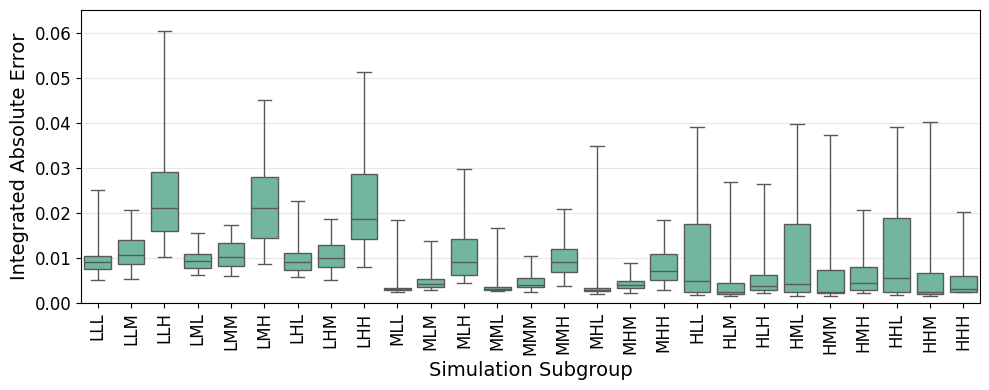

In [5]:
combined = pd.concat([
    final_result_df.assign(source='KM-GPT'),
], axis=0, ignore_index=True)


plt.figure(figsize=(10, 4))
ax = sns.boxplot(
    data=combined,
    x='group',
    y='integrated_abs_error',
    hue='source',
    order=group_order,
    palette=['#66c2a5'],
    whis=[2.5, 97.5],
    showfliers=False,
    legend=False
)

plt.xlabel('Simulation Subgroup', fontsize=14)
plt.ylabel('Integrated Absolute Error', fontsize=14)
plt.xticks(rotation=90, ha='center', fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,0.065)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

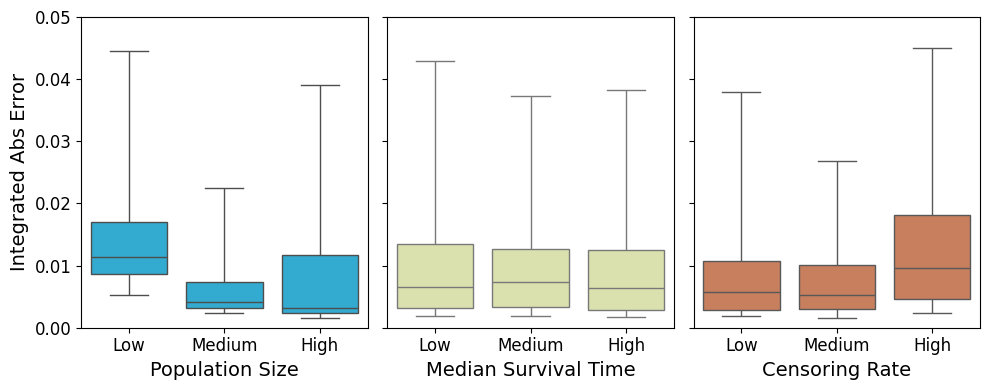

In [6]:
# Ensure 'group' is like 'LLL', 'LMH', etc. and integrated_abs_error exists.

# -----------------------------
# 1) Parse group into positions
# -----------------------------
combined = combined.copy()
combined['pos1'] = combined['group'].str[0]  # first letter
combined['pos2'] = combined['group'].str[1]  # middle letter
combined['pos3'] = combined['group'].str[2]  # last letter

# For consistent ordering on plots/tables
level_order = ['L', 'M', 'H']

# --------------------------------------------
# 2) Helper to aggregate by a given position
# --------------------------------------------
def agg_by_position(df, pos_col, value_col='integrated_abs_error'):
    med = (
        df.groupby(pos_col)[value_col]
          .quantile(0.5)
          .reset_index(name='median')
    )
    q = (
        df.groupby(pos_col)[value_col]
          .quantile([0.025, 0.975])
          .unstack()
          .reset_index()
          .rename(columns={0.025: 'q2p5', 0.975: 'q97p5'})
    )
    out = med.merge(q, on=pos_col)
    # order levels L, M, H (and keep any unexpected levels at the end)
    out[pos_col] = pd.Categorical(out[pos_col], categories=level_order, ordered=True)
    out = out.sort_values(pos_col)
    return out

agg_pos1 = agg_by_position(combined, 'pos1')
agg_pos2 = agg_by_position(combined, 'pos2')
agg_pos3 = agg_by_position(combined, 'pos3')

# -----------------------------
# Box plots with 95% CI (q2.5–q97.5)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

# pos1
sns.boxplot(
    data=combined, x='pos1', y='integrated_abs_error',
    order=level_order, whis=(2.5, 97.5), ax=axes[0],
    color="#19B8E9", showfliers=False
)
axes[0].set_xlabel("Population Size", fontsize=14)
axes[0].set_ylabel("Integrated Abs Error", fontsize=14)
axes[0].set_xticklabels(['Low', 'Medium', 'High'], fontsize=12)

# pos2
sns.boxplot(
    data=combined, x='pos2', y='integrated_abs_error',
    order=level_order, whis=(2.5, 97.5), ax=axes[1],
    color="#E2E9A6", showfliers=False
)
axes[1].set_xlabel("Median Survival Time", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_xticklabels(['Low', 'Medium', 'High'], fontsize=12)

# pos3
sns.boxplot(
    data=combined, x='pos3', y='integrated_abs_error',
    order=level_order, whis=(2.5, 97.5), ax=axes[2],
    color="#D8784C", showfliers=False
)
axes[2].set_xlabel("Censoring Rate", fontsize=14)
axes[2].set_ylabel("", fontsize=14)
axes[2].set_xticklabels(['Low', 'Medium', 'High'], fontsize=12)

for ax in axes:
    ax.tick_params(axis='y', labelsize=12)

plt.ylim(0,0.05)
plt.tight_layout()
plt.show()



In [7]:
q_values = final_result_df['integrated_abs_error'].quantile([0.025, 0.5, 0.975])
print(f"IAE: {q_values.loc[0.5]:.4f} [{q_values.loc[0.025]:.4f}, {q_values.loc[0.975]:.4f}]")

IAE: 0.0067 [0.0018, 0.0394]


# LMT Average

## Overall

In [8]:
# Add an outer loop to iterate through multiple names
meta_df = pd.read_csv('../SimulationData/simulation_metadata.csv')
meta_df
quantile_list = np.linspace(0,0.99,100)
failed_list = []

final_result_df = pd.DataFrame()
for index, row in tqdm(meta_df.iterrows()):
    unique_id = row['dataset_id']
    group_label = convert_id_to_group_label(unique_id)
    try:
        truth_df = pd.read_csv(sim_data_path + f'ipd/simulated_ipd_{unique_id}.csv')
        reconstruct_df = pd.read_csv(sim_data_path + f"recon_GPT5_base/ipd/{unique_id}_recon_ipd.csv")
        reconstruct_df = reconstruct_df.rename(columns={'time': 'Time', 'status': 'Event'})
    except:
        failed_list.append(unique_id)
        continue

    truth_df['normed_time'] = truth_df['Time'] / truth_df['Time'].max()
    reconstruct_df['normed_time'] = reconstruct_df['Time'] / reconstruct_df['Time'].max()

    result = calculate_survival_mae_landmarks(truth_df, reconstruct_df, percentiles=quantile_list)
    result['group'] = group_label
    final_result_df = pd.concat([final_result_df, result], axis=0, ignore_index=True)

1620it [02:15, 11.94it/s]


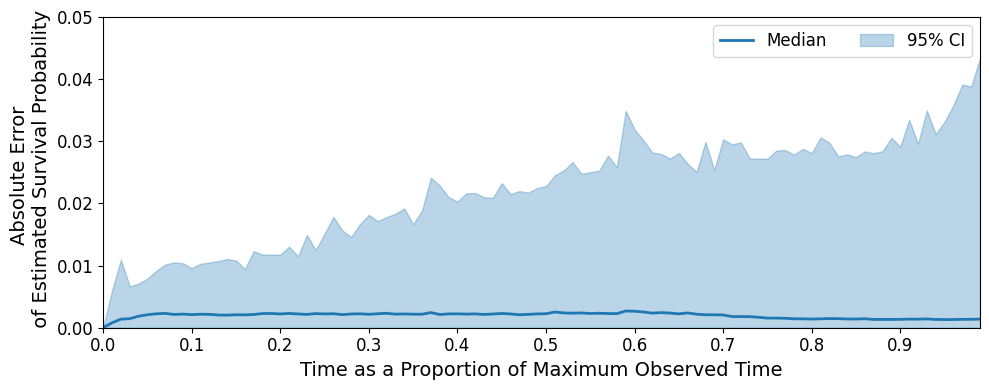

In [9]:
# Create line plot for median absolute error by percentile with 95% CI
plt.figure(figsize=(10, 4))

# Calculate statistics by percentile
percentile_stats = final_result_df.groupby('percentile')['absolute_error'].agg([
    lambda x: np.percentile(x, 50), 
    lambda x: np.percentile(x, 2.5),   # 2.5th percentile
    lambda x: np.percentile(x, 97.5)   # 97.5th percentile
]).reset_index()

# Rename columns for clarity
percentile_stats.columns = ['percentile', 'median', 'lower_95', 'upper_95']

# Sort by percentile for proper line plotting
percentile_stats = percentile_stats.sort_values('percentile')

# Create the line plot
plt.plot(percentile_stats['percentile'], percentile_stats['median'], 
         color="C0", linewidth=2, label='Median')

# Fill the 95% uncertainty range
plt.fill_between(percentile_stats['percentile'], 
                 percentile_stats['lower_95'], 
                 percentile_stats['upper_95'],
                 color='C0', alpha=0.3, label='95% CI')

# Customize the plot
plt.xlabel('Time as a Proportion of Maximum Observed Time', fontsize=14)
plt.ylabel('Absolute Error \n of Estimated Survival Probability', fontsize=14)
# plt.title('Absolute Error ', fontsize=14)

# Add legend
# handles, labels = plt.gca().get_legend_handles_labels()
# plt.legend(handles, labels, fontsize=10,
#            bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2)
plt.legend(fontsize=12, loc='upper right', ncol=2)
# Set x-axis to show every 0.1 increment
plt.xticks(np.arange(0, 1, 0.1), fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlim(0, 0.99)  # Start x-axis from 0
plt.ylim(0, 0.05)

# Adjust layout to prevent legend cutoff
plt.tight_layout()
plt.show()

In [10]:
final_result_df['absolute_error'].dropna().quantile([0.025, 0.5, 0.975])

0.025    0.000000
0.500    0.001940
0.975    0.023252
Name: absolute_error, dtype: float64

# Median OS

In [11]:
from lifelines import KaplanMeierFitter

def median_on_normed_time(df: pd.DataFrame) -> float:
    """
    Return the median survival time on the normalized [0,1] scale.
    If the KM curve never drops to 0.5, return 1.0 (i.e., median not reached).
    Expects columns: 'normed_time' and 'Event'.
    """
    kmf = KaplanMeierFitter()
    kmf.fit(durations=df['normed_time'], event_observed=df['Event'])
    sf = kmf.survival_function_.reset_index()
    sf.columns = ['time', 'S']

    # first time survival <= 0.5
    hit = sf[sf['S'] <= 0.5]
    if not hit.empty:
        return float(hit.iloc[0]['time'])
    else:
        # median not reached within observed window on [0,1]
        return np.nan

In [12]:
median_rows = []

# Add an outer loop to iterate through multiple names
meta_df = pd.read_csv('../SimulationData/simulation_metadata.csv')

final_result_df = pd.DataFrame()

for index, row in tqdm(meta_df.iterrows()):
    unique_id = row['dataset_id']
    group_label = convert_id_to_group_label(unique_id)
    try:
        truth_df = pd.read_csv(sim_data_path + f'ipd/simulated_ipd_{unique_id}.csv')
        reconstruct_df = pd.read_csv(sim_data_path + f"recon_GPT5_base/ipd/{unique_id}_recon_ipd.csv")
        reconstruct_df = reconstruct_df.rename(columns={'time': 'Time', 'status': 'Event'})
    except Exception as e:
        # print(e)
        failed_list.append(unique_id)
        continue

    # normalized time
    truth_df['normed_time'] = truth_df['Time'] / max(truth_df['Time'].max(), 1e-12)
    reconstruct_df['normed_time'] = reconstruct_df['Time'] / max(reconstruct_df['Time'].max(), 1e-12)

    # your existing landmark MAE calculation
    result = calculate_survival_mae_landmarks(truth_df, reconstruct_df, percentiles=quantile_list)
    result['group'] = group_label
    result['dataset_id'] = unique_id
    final_result_df = pd.concat([final_result_df, result], axis=0, ignore_index=True)

    # ---- NEW: median on normed time and differences ----
    med_truth = median_on_normed_time(truth_df)
    med_recon = median_on_normed_time(reconstruct_df)
    med_diff = med_recon - med_truth
    median_rows.append({
        'dataset_id': unique_id,
        'group': group_label,
        'median_truth_normed': med_truth,
        'median_recon_normed': med_recon,
        'median_diff_normed': abs(med_diff),
    })

median_result_df = pd.DataFrame(median_rows)

1620it [02:20, 11.55it/s]


In [13]:
median_result_df['median_diff_normed'].dropna().quantile([0.025, 0.5, 0.975])

0.025    0.000000
0.500    0.000703
0.975    0.035287
Name: median_diff_normed, dtype: float64

# Cumulative Hazard

In [14]:
from lifelines import NelsonAalenFitter

def integrated_abs_error_nelson_aalen(truth_df: pd.DataFrame, reconstruct_df: pd.DataFrame) -> float:
    """
    Compute the integrated absolute error between two Nelson-Aalen cumulative hazard curves
    on a shared normalized time scale.
    """
    tdf, rdf, _ = align_time_to_shared_scale(truth_df, reconstruct_df)

    naf_true = NelsonAalenFitter()
    naf_reco = NelsonAalenFitter()
    naf_true.fit(durations=tdf['t_norm'], event_observed=tdf['Event'])
    naf_reco.fit(durations=rdf['t_norm'], event_observed=rdf['Event'])

    grid = np.unique(
        np.clip(
            np.concatenate([
                np.array([0.0, 1.0]),
                tdf['t_norm'].to_numpy(),
                rdf['t_norm'].to_numpy(),
            ]),
            0.0,
            1.0,
        )
    )
    grid.sort()

    h_true = naf_true.cumulative_hazard_at_times(grid).to_numpy()
    h_reco = naf_reco.cumulative_hazard_at_times(grid).to_numpy()

    abs_diff = np.abs(h_true - h_reco)
    if hasattr(np, 'trapezoid'):
        iae = np.trapezoid(abs_diff, grid)
    else:
        iae = np.trapz(abs_diff, grid)
    return float(iae)

cumhaz_rows = []
cumhaz_failed_list = []
meta_df = pd.read_csv(sim_data_path + 'simulation_metadata.csv')

for index, row in tqdm(meta_df.iterrows(), total=len(meta_df)):
    unique_id = row['dataset_id']
    group_label = convert_id_to_group_label(unique_id)

    try:
        truth_df = pd.read_csv(sim_data_path + f'ipd/simulated_ipd_{unique_id}.csv')
        reconstruct_df = pd.read_csv(sim_data_path + f"recon_GPT5_base/ipd/{unique_id}_recon_ipd.csv")
        reconstruct_df = reconstruct_df.rename(columns={'time': 'Time', 'status': 'Event'})

        iae = integrated_abs_error_nelson_aalen(truth_df, reconstruct_df)
        cumhaz_rows.append({
            'dataset_id': unique_id,
            'group': group_label,
            'cumulative_hazard_iae': iae,
        })
    except Exception as e:
        print(e)
        cumhaz_failed_list.append(unique_id)
        continue

cumhaz_result_df = pd.DataFrame.from_records(cumhaz_rows)
cumhaz_group_order = cumhaz_result_df['group'].unique()

print(len(cumhaz_failed_list), 'datasets failed to process')
print(1 - len(cumhaz_failed_list) / len(meta_df), 'success rate')

cumhaz_result_df['cumulative_hazard_iae'].dropna().quantile([0.025, 0.5, 0.975])

100%|██████████| 1620/1620 [00:16<00:00, 100.37it/s]

0 datasets failed to process
1.0 success rate


0.025    0.011007
0.500    0.070901
0.975    0.294029
Name: cumulative_hazard_iae, dtype: float64

## Visualization

,dataset_id,group,cumulative_hazard_iae
0,exponential_high_medium_low_1_1,HML,0.445492
1,piecewise_high_medium_low_5_1,HML,0.441100
2,exponential_high_low_low_1_1,HLL,0.432791


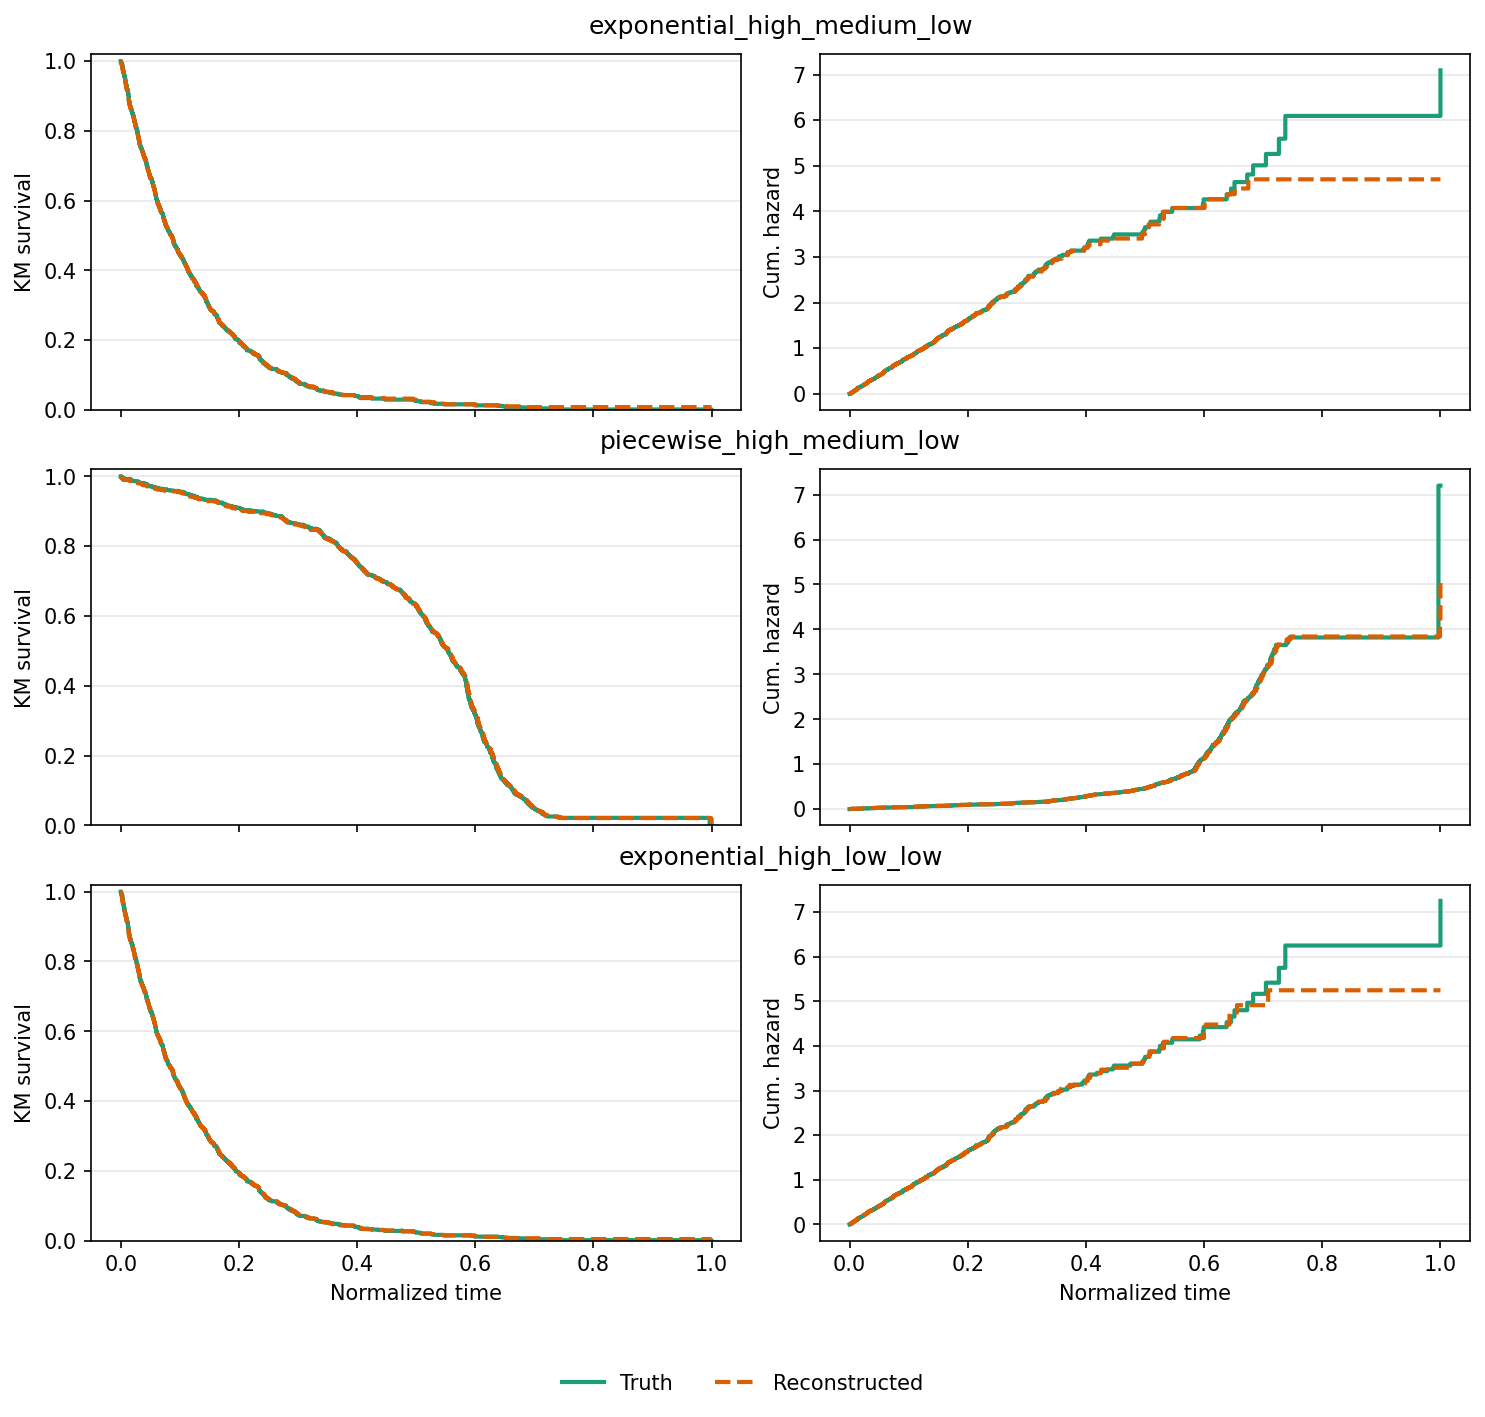

In [33]:
top_cumhaz_worst_df = (
    cumhaz_result_df
    .sort_values('cumulative_hazard_iae', ascending=False)
    .head(3)
    .reset_index(drop=True)
    .copy()
)

display(top_cumhaz_worst_df)

fig, axes = plt.subplots(
    len(top_cumhaz_worst_df),
    2,
    figsize=(10, 3.2 * len(top_cumhaz_worst_df)),
    sharex='col',
    squeeze=False,
    dpi=150,
 )

row_labels = []

for row_idx, (_, worst_row) in enumerate(top_cumhaz_worst_df.iterrows()):
    unique_id = worst_row['dataset_id']
    row_label = '_'.join(unique_id.split('_')[:-2])
    row_labels.append(row_label)

    truth_df = pd.read_csv(sim_data_path + f'ipd/simulated_ipd_{unique_id}.csv')
    reconstruct_df = pd.read_csv(sim_data_path + f"recon_GPT5_base/ipd/{unique_id}_recon_ipd.csv")
    reconstruct_df = reconstruct_df.rename(columns={'time': 'Time', 'status': 'Event'})

    tdf, rdf, shared_max_time = align_time_to_shared_scale(truth_df, reconstruct_df)

    kmf_true = KaplanMeierFitter()
    kmf_reco = KaplanMeierFitter()
    kmf_true.fit(durations=tdf['t_norm'], event_observed=tdf['Event'])
    kmf_reco.fit(durations=rdf['t_norm'], event_observed=rdf['Event'])

    naf_true = NelsonAalenFitter()
    naf_reco = NelsonAalenFitter()
    naf_true.fit(durations=tdf['t_norm'], event_observed=tdf['Event'])
    naf_reco.fit(durations=rdf['t_norm'], event_observed=rdf['Event'])

    grid = np.unique(
        np.clip(
            np.concatenate([
                np.array([0.0, 1.0]),
                tdf['t_norm'].to_numpy(),
                rdf['t_norm'].to_numpy(),
            ]),
            0.0,
            1.0,
        )
    )
    grid.sort()

    s_true = kmf_true.predict(grid, interpolate=False).to_numpy()
    s_reco = kmf_reco.predict(grid, interpolate=False).to_numpy()
    h_true = naf_true.cumulative_hazard_at_times(grid).to_numpy()
    h_reco = naf_reco.cumulative_hazard_at_times(grid).to_numpy()

    km_ax = axes[row_idx, 0]
    ch_ax = axes[row_idx, 1]

    km_ax.step(grid, s_true, where='post', linewidth=2, label='Truth', color='#1b9e77', linestyle='-')
    km_ax.step(grid, s_reco, where='post', linewidth=2, label='Reconstructed', color='#d95f02', linestyle='--')
    km_ax.set_ylabel('KM survival')
    km_ax.set_ylim(0, 1.02)
    km_ax.grid(axis='y', alpha=0.3)

    ch_ax.step(grid, h_true, where='post', linewidth=2, label='Truth', color='#1b9e77', linestyle='-')
    ch_ax.step(grid, h_reco, where='post', linewidth=2, label='Reconstructed', color='#d95f02', linestyle='--')
    ch_ax.set_ylabel('Cum. hazard')
    ch_ax.grid(axis='y', alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    ncol=2,
    frameon=False,
    fontsize=10,
 )
axes[-1, 0].set_xlabel('Normalized time')
axes[-1, 1].set_xlabel('Normalized time')
fig.tight_layout(rect=(0, 0.07, 1, 0.97), h_pad=2.2)
fig.canvas.draw()

for row_idx, row_label in enumerate(row_labels):
    left_box = axes[row_idx, 0].get_position()
    right_box = axes[row_idx, 1].get_position()
    row_y = min(max(left_box.y1, right_box.y1) + 0.01, 0.975)
    fig.text(
        (left_box.x0 + right_box.x1) / 2,
        row_y,
        row_label,
        ha='center',
        va='bottom',
        fontsize=12,
        # fontweight='semibold',
    )

plt.show()

# Event Distribution

In [16]:
from scipy.stats import wasserstein_distance

def observed_event_times(df: pd.DataFrame, time_col: str = 't_norm') -> np.ndarray:
    """
    Return sorted observed event times from the specified time column.
    """
    return np.sort(
        df.loc[df['Event'].astype(int) == 1, time_col].to_numpy(dtype=float)
    )

def observed_event_wasserstein_distance(
    truth_df: pd.DataFrame, reconstruct_df: pd.DataFrame
 ) -> float:
    """
    Compute the 1D Wasserstein (Earth Mover) distance between observed event times
    on a shared normalized time scale.
    
    This focuses on the timing/order of observed events among event patients.
    If one dataset has no observed events and the other does, return the maximum
    normalized mismatch of 1.0.
    """
    tdf, rdf, _ = align_time_to_shared_scale(truth_df, reconstruct_df)

    truth_event_times = observed_event_times(tdf)
    reco_event_times = observed_event_times(rdf)

    if len(truth_event_times) == 0 and len(reco_event_times) == 0:
        return 0.0
    if len(truth_event_times) == 0 or len(reco_event_times) == 0:
        return 1.0

    return float(wasserstein_distance(truth_event_times, reco_event_times))

eventdist_rows = []
eventdist_failed_list = []
meta_df = pd.read_csv(sim_data_path + 'simulation_metadata.csv')

for index, row in tqdm(meta_df.iterrows(), total=len(meta_df)):
    unique_id = row['dataset_id']
    group_label = convert_id_to_group_label(unique_id)

    try:
        truth_df = pd.read_csv(sim_data_path + f'ipd/simulated_ipd_{unique_id}.csv')
        reconstruct_df = pd.read_csv(sim_data_path + f"recon_GPT5_base/ipd/{unique_id}_recon_ipd.csv")
        reconstruct_df = reconstruct_df.rename(columns={'time': 'Time', 'status': 'Event'})

        wd = observed_event_wasserstein_distance(truth_df, reconstruct_df)
        eventdist_rows.append({
            'dataset_id': unique_id,
            'group': group_label,
            'observed_event_wasserstein': wd,
        })
    except Exception as e:
        print(e)
        eventdist_failed_list.append(unique_id)
        continue

eventdist_result_df = pd.DataFrame.from_records(eventdist_rows)
eventdist_group_order = eventdist_result_df['group'].unique()

print(len(eventdist_failed_list), 'datasets failed to process')
print(1 - len(eventdist_failed_list) / len(meta_df), 'success rate')

eventdist_result_df['observed_event_wasserstein'].dropna().quantile([0.025, 0.5, 0.975])

100%|██████████| 1620/1620 [00:03<00:00, 411.36it/s]

0 datasets failed to process
1.0 success rate


0.025    0.000794
0.500    0.005895
0.975    0.049212
Name: observed_event_wasserstein, dtype: float64

# Censoring Pattern

In [17]:
overall_censor_rows = []
overall_censor_failed_list = []
meta_df = pd.read_csv(sim_data_path + 'simulation_metadata.csv')

for index, row in tqdm(meta_df.iterrows(), total=len(meta_df)):
    unique_id = row['dataset_id']
    group_label = convert_id_to_group_label(unique_id)

    try:
        truth_df = pd.read_csv(sim_data_path + f'ipd/simulated_ipd_{unique_id}.csv')
        reconstruct_df = pd.read_csv(
            sim_data_path + f'recon_GPT5_base/ipd/{unique_id}_recon_ipd.csv'
        )
        reconstruct_df = reconstruct_df.rename(columns={'time': 'Time', 'status': 'Event'})

        truth_censor_rate = (truth_df['Event'].astype(int) == 0).mean()
        recon_censor_rate = (reconstruct_df['Event'].astype(int) == 0).mean()

        overall_censor_rows.append({
            'dataset_id': unique_id,
            'group': group_label,
            'truth_censoring_rate': truth_censor_rate,
            'reconstructed_censoring_rate': recon_censor_rate,
            'absolute_difference': abs(truth_censor_rate - recon_censor_rate),
        })
    except Exception as e:
        print(e)
        overall_censor_failed_list.append(unique_id)
        continue

overall_censor_result_df = pd.DataFrame.from_records(overall_censor_rows)
overall_censor_quantiles = overall_censor_result_df['absolute_difference'].quantile([0.025, 0.5, 0.975])

print(len(overall_censor_failed_list), 'datasets failed to process')
print(1 - len(overall_censor_failed_list) / len(meta_df), 'success rate')
print(
    f"Overall censoring rate abs diff: {overall_censor_quantiles.loc[0.5]:.4f} "
    f"[{overall_censor_quantiles.loc[0.025]:.4f}, {overall_censor_quantiles.loc[0.975]:.4f}]"
 )

overall_censor_quantiles

100%|██████████| 1620/1620 [00:02<00:00, 645.57it/s]

0 datasets failed to process
1.0 success rate
Overall censoring rate abs diff: 0.0093 [0.0000, 0.0548]


0.025    0.000000
0.500    0.009281
0.975    0.054842
Name: absolute_difference, dtype: float64